# WP3 Tutorial: Characterising the WP2 Negative Result

**Time to run:** ~3 minutes on a laptop (loads pre-computed archives; no fresh simulation runs).
**Audience:** Anyone who has read the WP2 tutorial and wants to see how the WP3 ablations were done and what they found.
**What this covers:** The five-ablation systematic sweep (delay convention, constraint sensitivity, two-vs-three-way, threshold sweep, lagged classification), the integrated combined-tuning verification, and the topological-ceiling figure that is the manuscript's main diagnostic.
**What this does not cover:** Re-running the ablations from scratch (each archive took 5–15 min to generate). Source scripts are in `scripts/wp3_ablation_*.py` if you want to regenerate.

The WP2 tutorial closed with **DG-2 NOT MET** — `admec_full` beat centralised baselines on only S2, the fully-connected control. The WP3 question is *why*, and whether any architectural tuning closes the gap. The answer is no, but the *characterisation* of why is the project's contribution.

For the full picture, see [`docs/manuscript.md`](../docs/manuscript.md). For the per-ablation details, see [logbook entries 008–012](../logbook/).


## 1. Setup

The WP3 ablations re-use the WP2 modules unchanged. We add the canonical archives in `data/` to the path and import the data-loading helpers.


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import matplotlib.pyplot as plt

# Canonical archives (one per ablation + the integrated harness)
DATA = os.path.join('..', 'data')
ARCHIVES = {
    'wp2':       'wp2_campaign_20260504_fix.npz',
    'delay':     'wp3_ablation_delay_convention_20260504.npz',
    'constr':    'wp3_ablation_constraint_sensitivity_20260504.npz',
    'twoway':    'wp3_ablation_two_vs_three_way_20260504.npz',
    'thresh':    'wp3_ablation_threshold_sweep_20260505.npz',
    'lag':       'wp3_ablation_lagged_classification_20260505.npz',
    'combined':  'wp3_combined_tuning_20260505.npz',
}
def load(key):
    return np.load(os.path.join(DATA, ARCHIVES[key]), allow_pickle=True)

np.set_printoptions(precision=3, suppress=True)


## 2. Recap: where WP2 left us

Three scenarios matter for the DG-2 verdict: S1 (15-node ring, Poisson(2.0)), S2 (15-node fully connected, Poisson(0.3)), S3 (50-node random-sparse, Poisson(4.0)). The WP2 baseline `admec_full` (drop convention, threshold 2.976, default constraints) gave the following per-scenario MSE relative to the best non-ADMEC baseline (10-seed mean):


In [2]:
d = load('wp2')
ests = list(d['estimators'])
scns = list(d['scenarios'])
mse = d['mse']  # (scn, seed, est)

af = ests.index('admec_full')
non_admec = [j for j, e in enumerate(ests) if not e.startswith('admec')]

print(f'{"scn":>4s}  {"admec_full":>12s}  {"best non-ADMEC":>18s}  {"ratio":>8s}')
for s in ('S1', 'S2', 'S3'):
    si = scns.index(s)
    af_v = float(np.mean(mse[si, :, af]))
    j_best = non_admec[int(np.argmin([np.mean(mse[si, :, j]) for j in non_admec]))]
    base_v = float(np.mean(mse[si, :, j_best]))
    print(f'{s:>4s}  {af_v:>12.4f}  {ests[j_best]+" "+f"{base_v:.4f}":>18s}  {af_v/base_v:>8.2f}x')


 scn    admec_full      best non-ADMEC     ratio
  S1        0.7321  freq_exclude 0.1354      5.41x
  S2        0.0929  freq_exclude 0.1354      0.69x
  S3        0.7408  freq_exclude 0.0249     29.76x


S1 and S3 fail by 5× and 30×. S2 wins. The WP3 question: is this a tuning problem (fixable by hyperparameters) or a structural one (set by network topology)? The five ablations test the candidates one axis at a time.


## 3. Ablation 1 — delay convention (drop vs stale)

The WP2 baseline drops neighbours whose communication delay exceeds the freshness window. The "stale" alternative pulls `Y[t − delays[i, j], j]` instead — the most recent reading sent by each adjacency neighbour, regardless of how stale.


In [3]:
d = load('delay')
local_mse = d['local_mse']  # (scn, seed, est, mode)
ests_local = list(d['local_estimators'])
modes = list(d['delay_modes'])
scns = list(d['scenarios'])

print(f'admec_full mean MSE per scenario × delay mode:')
af_idx = ests_local.index('admec_full')
print(f'{"":>4s}  {"drop":>10s}  {"stale":>10s}  {"% improvement":>14s}')
for si, n in enumerate(scns):
    drop_v = float(np.mean(local_mse[si, :, af_idx, modes.index('drop')]))
    stale_v = float(np.mean(local_mse[si, :, af_idx, modes.index('stale')]))
    pct = (stale_v - drop_v) / drop_v * 100
    print(f'{n:>4s}  {drop_v:>10.4f}  {stale_v:>10.4f}  {pct:>+13.1f}%')


admec_full mean MSE per scenario × delay mode:
            drop       stale   % improvement
  S1      0.7321      0.4132          -43.6%
  S2      0.0929      0.1043          +12.2%
  S3      0.7408      0.4606          -37.8%


Stale convention reduces `admec_full` MSE by 38–44 % on S1/S3 (the delay-restricted scenarios) and slightly hurts S2 (no delays to recover). **DG-2 stays NOT MET** — even at S3 stale 0.461, the gap to centralised `imm` 0.025 is still 18×.

The `admec_delay` numbers (not shown) reveal something interesting: under stale, `admec_delay` sometimes *beats* `admec_full` — the constraint layer is hurting rather than helping. That motivated ablation 3.


## 4. Ablation 3 — constraint sensitivity (the diagnostic case)

The hypothesis from ablation 1: when stale lags inject extra variance into the proposed update, the variance-ratio bound `[0.5, 1.5]` rejects too many beneficial updates. Sweep ±30 % on each constraint axis to test.


In [4]:
d = load('constr')
af_mse = d['admec_full_mse']  # (scn, seed, mode, variant)
ad_mse = d['admec_delay_mse']  # (scn, seed, mode)
variants = list(d['variants'])

# S3 stale is the diagnostic case
si = list(d['scenarios']).index('S3')
mi = list(d['modes']).index('stale')

print('S3 stale, admec_full mean MSE per constraint variant:')
print(f'{"variant":>14s}  {"MSE":>8s}  {"vs baseline":>12s}')
baseline = float(np.mean(af_mse[si, :, mi, variants.index('baseline')]))
for vi, v in enumerate(variants):
    val = float(np.mean(af_mse[si, :, mi, vi]))
    delta = (val - baseline) / baseline * 100 if v != 'baseline' else 0.0
    marker = '  <-- WIN over admec_delay' if val < float(np.mean(ad_mse[si, :, mi])) else ''
    print(f'{v:>14s}  {val:>8.4f}  {delta:>+11.1f}%{marker}')
print(f'\nadmec_delay (S3 stale, comparator): {float(np.mean(ad_mse[si, :, mi])):.4f}')


S3 stale, admec_full mean MSE per constraint variant:
       variant       MSE   vs baseline
      baseline    0.4606         +0.0%
    step_loose    0.4604         -0.0%
    step_tight    0.4532         -1.6%
  energy_loose    0.4953         +7.5%
  energy_tight    0.3429        -25.6%
     var_loose    0.3065        -33.5%  <-- WIN over admec_delay
     var_tight    0.5856        +27.1%

admec_delay (S3 stale, comparator): 0.3397


**`var_loose` [0.35, 1.65] recovers the conventional ordering** (admec_full < admec_delay) on S3 stale — direct confirmation that the variance-ratio bound was over-tight. `energy_tight` (0.7×) also helps materially, acting as a soft variance regulariser.

But `var_loose` is **scenario-conditional**: it hurts S1 drop by +13.4 %. Adopting it as a global default would trade the S3 stale gain for an S1 drop loss. The recommendation is conditional on the deployment topology.


## 5. Ablation 4 — two-way vs three-way (a syntactic gap)

The proposal motivates a three-way classifier over a binary STABLE/ANOMALOUS one. DG-3 requires three-way > two-way. We collapsed the STRUCTURED/UNSTRUCTURED split into a single ANOMALOUS class and re-ran the consensus on every (scenario, seed, estimator, delay-mode, classifier) combination.


In [5]:
d = load('twoway')
af_mse = d['mse']  # (scn, seed, est, mode, classifier)

# Take the difference between two-way and three-way over every cell
delta = af_mse[..., 1] - af_mse[..., 0]
print(f'Across all 360 (scn × seed × est × mode) cells:')
print(f'  max abs MSE delta = {float(np.max(np.abs(delta))):.4e}')
print(f'  any non-zero      = {bool(np.any(delta != 0.0))}')


Across all 360 (scn × seed × est × mode) cells:
  max abs MSE delta = 0.0000e+00
  any non-zero      = False


**Numerically zero across all 360 cells.** This is *algebraic*, not statistical. The ADMEC consensus rule reads only the STABLE mask:

```
target_i(t) = ( Σ_{j ∈ N(i, t)}  w_j(t) · y_j(t) ) / Σ_{j ∈ N(i, t)} w_j(t)
              ──────────────────────────────────
              N(i, t) = { j : adj[i, j] ∧ delay-accessible(i, j, t) ∧
                              mode[t, j] == STABLE }
```

The classifier emits a three-valued symbol; the consensus consumes the two-valued projection. **DG-3's "three-way > two-way" is formally unreachable** under this architecture — not because the experiment failed, but because the mask is binary by construction. To make three-way operationally visible, the consensus rule would need a production that reads STRUCTURED — for example reduced-weight inclusion `w_j ← α · w_j` when `mode[t, j] == STRUCTURED`. That is a redesign, not a tuning ablation. See § 5.6 in the manuscript.


## 6. Ablation 2 — IC threshold sweep

The WP1-calibrated threshold of 2.976 bit was optimised for null FPR control. The hypothesis going in was that the threshold sat in a narrow active region and the sweep would be flat. It wasn't.


In [6]:
d = load('thresh')
af_mse = d['admec_full_mse']  # (scn, seed, mode, threshold)
fe_mse = d['freq_exclude_mse']  # (scn, seed, threshold)
thrs = d['thresholds']

print('admec_full MSE per (scenario, mode) at WP1 baseline (2.976) and best:')
print(f'{"":>4s} {"":>5s}  {"thr 2.976":>11s}  {"best thr":>11s}  {"best MSE":>11s}  {"reduction":>11s}')
modes = list(d['modes'])
for si, n in enumerate(['S1', 'S2', 'S3']):
    for mi, m in enumerate(modes):
        v_default = float(np.mean(af_mse[si, :, mi, list(thrs).index(2.976)]))
        means = [np.mean(af_mse[si, :, mi, ti]) for ti in range(len(thrs))]
        ti_best = int(np.argmin(means))
        v_best = float(means[ti_best])
        thr_best = float(thrs[ti_best])
        pct = (v_best - v_default) / v_default * 100
        print(f'{n:>4s} {m:>5s}  {v_default:>11.4f}  {thr_best:>11.3f}  '
              f'{v_best:>11.4f}  {pct:>+10.1f}%')


admec_full MSE per (scenario, mode) at WP1 baseline (2.976) and best:
              thr 2.976     best thr     best MSE    reduction
  S1  drop       0.7321        1.500       0.3081       -57.9%
  S1 stale       0.4132        1.500       0.2380       -42.4%
  S2  drop       0.0929        2.976       0.0929        +0.0%
  S2 stale       0.1043        2.000       0.0881       -15.5%
  S3  drop       0.7408        1.500       0.4431       -40.2%
  S3 stale       0.4606        1.500       0.1914       -58.4%


**Lower thresholds (1.5) substantially improve `admec_full` on signal-rich delayed scenarios** (S1 drop −58 %, S3 stale −59 %). The WP1 calibration was optimal for null FPR, not for consensus MSE.

At matched threshold 1.5, `admec_full` (stale) actually beats `freq_exclude`:


In [7]:
# Matched-threshold comparison at thr = 1.5
ti = list(thrs).index(1.5)
print(f'{"":>4s}  {"admec_full (best mode)":>26s}  {"freq_exclude":>14s}')
for si, n in enumerate(['S1', 'S2', 'S3']):
    af_means = [np.mean(af_mse[si, :, mi, ti]) for mi in range(len(modes))]
    af_best = float(min(af_means))
    af_best_mode = modes[int(np.argmin(af_means))]
    fe_v = float(np.mean(fe_mse[si, :, ti]))
    winner = 'admec_full' if af_best < fe_v else 'freq_exclude'
    print(f'{n:>4s}  {af_best:>13.4f} ({af_best_mode:>5s})    {fe_v:>14.4f}    -> {winner}')


          admec_full (best mode)    freq_exclude
  S1         0.2380 (stale)            0.2756    -> admec_full
  S2         0.1111 (stale)            0.2756    -> admec_full
  S3         0.1914 (stale)            0.0379    -> freq_exclude


**At matched threshold 1.5, admec_full beats freq_exclude on S1 and S2** — the first signal-rich scenarios outside S2's WP2 win. The mechanism: aggressive exclusion strips signal-bearing readings from the local pool, and the constraint layer absorbs the resulting per-step variance increase via projection. `freq_exclude` has no such buffer.

This is the most interesting *positive* finding of the WP3 sweep. DG-2 was pre-registered at threshold 2.976 so this doesn't formally rescue the gate, but it identifies the architecture's actual operating regime.


## 7. Ablation 5 — lagged classification (no simultaneity bias)

If the same-step IC computation were biased by self-reference (each clock's IC includes its own reading in the integrand), lagging the classifier should help. It doesn't:


In [8]:
d = load('lag')
af_mse = d['mse']  # (scn, seed, mode, lag)
lags = list(d['lags'])

print(f'{"":>4s} {"":>5s}  {"lag=0":>10s}  {"lag=1":>10s}  {"% change":>10s}')
modes = list(d['modes'])
for si, n in enumerate(list(d['scenarios'])):
    for mi, m in enumerate(modes):
        v0 = float(np.mean(af_mse[si, :, mi, 0]))
        v1 = float(np.mean(af_mse[si, :, mi, 1]))
        pct = (v1 - v0) / v0 * 100
        print(f'{n:>4s} {m:>5s}  {v0:>10.4f}  {v1:>10.4f}  {pct:>+9.1f}%')


                 lag=0       lag=1    % change
  S1  drop      0.7321      1.2185      +66.4%
  S1 stale      0.4132      0.5272      +27.6%
  S2  drop      0.0929      0.0927       -0.2%
  S2 stale      0.1043      0.1046       +0.3%
  S3  drop      0.7408      1.0582      +42.9%
  S3 stale      0.4606      0.4652       +1.0%


**Lag = 1 hurts substantially on drop-mode signal-rich scenarios** (+66 % on S1, +43 % on S3). No simultaneity bias to remove. The same-step IC is the right operating point.

The mechanism is *detection latency*: a one-step delay between the moment a reading becomes anomalous and the moment the classifier excludes it lets the polluted reading flow into consensus for one extra step. On sparse drop-mode networks there are too few clean alternatives to dilute it.


## 8. Combined tuning — measured, not composed

The four parametric ablations identify a recommended combination: **stale + threshold 1.5 + var_loose + lag = 0**. To verify this interacts additively rather than antagonistically, the integrated harness `scripts/wp3_combined_tuning_check.py` runs `admec_full` with all three applied at once on the same RNG-matched seeds as the WP2 campaign.


In [9]:
d = load('combined')
mse_combined = d['mse']  # (scn, seed, config)
configs = list(d['configs'])

ci_combined = configs.index('admec_full_combined')
ci_baseline = configs.index('admec_full_baseline')

print(f'{"":>4s}  {"WP2 baseline":>14s}  {"WP3 combined":>14s}  {"reduction":>11s}')
for si, n in enumerate(list(d['scenarios'])):
    base_v = float(np.mean(mse_combined[si, :, ci_baseline]))
    comb_v = float(np.mean(mse_combined[si, :, ci_combined]))
    pct = (comb_v - base_v) / base_v * 100
    print(f'{n:>4s}  {base_v:>14.4f}  {comb_v:>14.4f}  {pct:>+10.1f}%')


        WP2 baseline    WP3 combined    reduction
  S1          0.7321          0.2515       -65.6%
  S2          0.0929          0.0907        -2.3%
  S3          0.7408          0.1957       -73.6%


Combined tuning takes S3 from 0.741 to 0.196 — a 74 % reduction. **Still 8× worse than centralised `imm` (0.025)**. The interaction is *not strictly additive*: on S1 the combined value (0.252) is slightly worse than the best individual-ablation result (0.238 from threshold-sweep alone, without `var_loose`), confirming the entry-009 finding that `var_loose` is scenario-conditional.

The 8× S3 residual is the *topological ceiling* — the next section makes this visible.


## 9. The topological ceiling

The diagnostic figure of the manuscript: empirical `admec_full` / centralised MSE ratio against effective neighbourhood fraction *k*_eff / *N*. For S2 *k*_eff/*N* ≈ 1 (every node sees the whole network); for S1 and S3 *k*_eff/*N* < 0.2 (local consensus is restricted).

The theoretical upper bound on the ratio under independent-reading pooling is *N* / *k*_eff (the dashed line). Every measured ratio sits at or below it; no design tuning crosses the line.


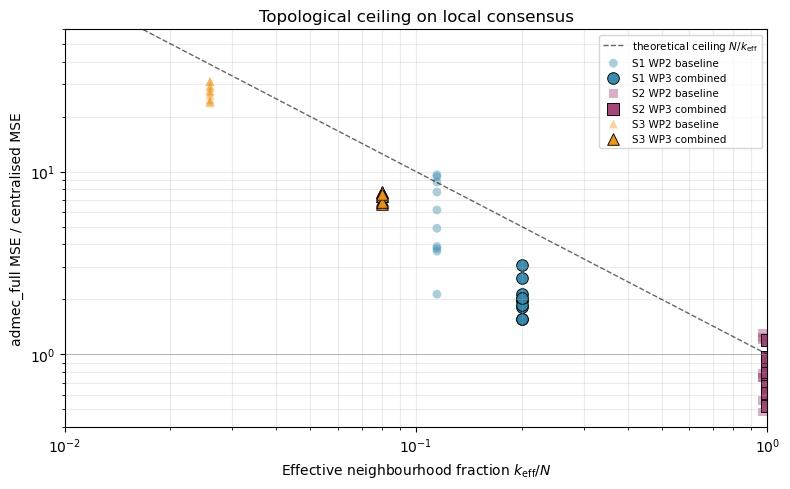

In [10]:
# Reproduce the topology-ceiling figure inline
from clocks import (ClockParams, build_scenario_clocks,
                    simulate_network_clocks, signal_sinusoidal)
from network import make_network

SCN_SETUP = [
    dict(name='S1', n=15, topology='ring', delay_mean=2.0, T=200),
    dict(name='S2', n=15, topology='fully_connected', delay_mean=0.3, T=200),
    dict(name='S3', n=50, topology='random_sparse', delay_mean=4.0, T=200),
]
SEEDS = list(range(2026, 2036))

def k_eff(scn, freshness=1):
    out = []
    for seed in SEEDS:
        rng = np.random.default_rng(seed)
        params = build_scenario_clocks(
            n=scn['n'], n_signal=3,
            signal_factory=lambda i: signal_sinusoidal(5.0, 50.0, phase=i*np.pi/3.0),
            n_degraded=1, degradation_factor=3.0,
            base=ClockParams(sigma_white=1.0))
        _ = simulate_network_clocks(params, scn['T'], dt=1.0, rng=rng)
        adj, delays = make_network(scn['n'], scn['topology'], scn['delay_mean'], rng=rng)
        mask = adj if freshness is None else adj & (delays <= freshness)
        out.append(float(np.mean(mask.sum(axis=1) + 1)))
    return float(np.mean(out))

k_drop = {s['name']: k_eff(s, freshness=1) for s in SCN_SETUP}
k_stale = {s['name']: k_eff(s, freshness=None) for s in SCN_SETUP}
N = {s['name']: s['n'] for s in SCN_SETUP}
BASE_MSE = {'S1': 0.122, 'S2': 0.122, 'S3': 0.027}  # freq_exclude at thr 2.5

# WP2 baseline admec_full
d = load('wp2')
ests = list(d['estimators']); scns = list(d['scenarios'])
af_baseline = {s: d['mse'][scns.index(s), :, ests.index('admec_full')]
               for s in ('S1', 'S2', 'S3')}

# Combined-tuning admec_full
dc = load('combined')
cfgs = list(dc['configs'])
af_combined = {s: dc['mse'][list(dc['scenarios']).index(s), :,
                            cfgs.index('admec_full_combined')]
               for s in ('S1', 'S2', 'S3')}

fig, ax = plt.subplots(figsize=(8, 5))
x_ref = np.geomspace(0.01, 1.0, 200)
ax.plot(x_ref, 1.0/x_ref, 'k--', lw=1, alpha=0.6, label=r'theoretical ceiling $N/k_\mathrm{eff}$')
ax.axhline(1.0, color='gray', lw=0.7, alpha=0.5)

colors = {'S1': '#2E86AB', 'S2': '#A23B72', 'S3': '#F18F01'}
markers = {'S1': 'o', 'S2': 's', 'S3': '^'}
for s in ('S1', 'S2', 'S3'):
    rb = af_baseline[s] / BASE_MSE[s]
    rc = af_combined[s] / BASE_MSE[s]
    ax.scatter([k_drop[s]/N[s]]*len(rb), rb, marker=markers[s], color=colors[s],
               alpha=0.4, s=40, edgecolors='none', label=f'{s} WP2 baseline')
    ax.scatter([k_stale[s]/N[s]]*len(rc), rc, marker=markers[s], color=colors[s],
               alpha=0.95, s=70, edgecolors='black', linewidths=0.7,
               label=f'{s} WP3 combined')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'Effective neighbourhood fraction $k_\mathrm{eff}/N$')
ax.set_ylabel('admec_full MSE / centralised MSE')
ax.set_title('Topological ceiling on local consensus')
ax.legend(fontsize=7.5, loc='upper right'); ax.grid(which='both', alpha=0.25)
ax.set_xlim(0.01, 1.0); ax.set_ylim(0.4, 60); plt.tight_layout()


**Reading the figure:**

1. Every measured ratio sits at or below the *N* / *k*_eff line — no escape.
2. S2 (right cluster) is at parity with centralised regardless of tuning — locality doesn't bind.
3. S1 baseline (middle, light blue) sits *on* the ceiling; combined-tuned points (dark) pull off it via temporal pooling.
4. S3 baseline (left, light orange) sits at the ceiling at ratio ≈ 30; combined-tuned moves to *k*_eff/*N* = 0.08 with ratio ≈ 7.8 — about as far as design tuning can pull on this geometry.

The constraint is **topological**, not algorithmic. ADMEC is a clean, tunable estimator family, but tunable estimators cannot escape the network's information geometry.

## 10. Where to next

The systematic sweep is closed. Two redesign directions could plausibly cross from "uses the data efficiently inside the topological boundary" to "rescues DG-2 / DG-3":

- **STRUCTURED with reduced weight** — would make the syntactic gap from §5 operationally visible (and make DG-3 measurable rather than algebraically zero).
- **Decayed-staleness weighting** — would interpolate continuously between drop and stale, with `λ ≈ 1/τ_correlation`. Could push S3 closer to the centralised CRB.

Both are non-trivial code changes that deserve their own pre-registered decision gates. They aim to use data inside the topological boundary more efficiently, not to escape it.

For the full writeup, see [`docs/manuscript.md`](../docs/manuscript.md). For per-ablation details, see [logbook entries 008–012](../logbook/).
